<a href="https://colab.research.google.com/github/sujitx-vs/Deep-Neural-Networks---PGCP_AI/blob/main/ANN_iris_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANN Iris Regurlarization.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,callbacks
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


Load Data Set.

In [ ]:
iris = load_iris()
X, y = iris.data, iris.target

Test, Train Split.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
X_train.shape


(120, 4)

Scaling using standard Scaler.


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
print("Train:", X_train.shape, "Test:",X_test.shape)

Train: (120, 4) Test: (30, 4)


In [ ]:
print(y_train)

[0 2 1 0 1 2 1 2 2 2 2 1 1 1 1 0 0 2 2 0 1 0 2 0 1 2 2 0 2 0 0 1 1 0 2 2 1
 1 2 1 0 1 0 2 0 0 2 0 0 0 0 1 2 1 0 2 1 2 0 2 0 1 2 0 1 1 2 1 1 2 0 0 0 2
 1 2 1 2 2 1 0 2 1 0 2 0 2 1 1 0 1 2 0 0 2 2 2 1 2 0 2 1 2 2 0 1 1 1 1 1 0
 2 1 1 0 0 0 0 1 0]


One hot encode labels

In [ ]:
y_train_oh = keras.utils.to_categorical(y_train, num_classes=3)
y_test_oh  = keras.utils.to_categorical(y_test,  num_classes=3)

In [ ]:
print(y_train_oh)

[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1.

Model Buliding.

In [ ]:
def build_model(input_dim=4, num_classes=3):
    model = keras.Sequential([
        # Input layer
        layers.Input(shape=(input_dim,)),

        # Hidden layer 1 — 16 neurons, ReLU activation
        layers.Dense(16, activation='relu'),
        layers.BatchNormalization(),   # stabilise activations across batches
        layers.Dropout(0.2),           # randomly zero 20% of neurons → reduces overfitting

        # Hidden layer 2 — 8 neurons, ReLU activation
        layers.Dense(8, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Output layer — 3 neurons (one per class), Softmax → probability distribution
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339 (1.32 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 48 (192.00 B)

Model Compilation

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Training of the model.

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,          # stop if val_loss doesn't improve for 20 epochs
    restore_best_weights=True  # revert to the epoch with best val_loss
)
#not required for small datasets
#lr_scheduler = callbacks.ReduceLROnPlateau(
 #   monitor='val_loss',
  #  factor=0.5,           # halve the LR when plateauing
   # patience=10,
    #min_lr=1e-6,
    #verbose=1
#)

history = model.fit(
    X_train, y_train_oh,
    epochs=100,
    batch_size=16,
    validation_split=0.15,  # use 15% of training data for validation
    callbacks=[early_stop] #, lr_scheduler],

)

print(f"\nTraining stopped at epoch: {early_stop.stopped_epoch}")

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 385ms/step - accuracy: 0.4510 - loss: 1.1965 - val_accuracy: 0.3889 - val_loss: 1.0358
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5196 - loss: 0.9910 - val_accuracy: 0.5000 - val_loss: 1.0003
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4902 - loss: 1.0382 - val_accuracy: 0.5000 - val_loss: 0.9612
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5294 - loss: 1.0758 - val_accuracy: 0.5556 - val_loss: 0.9333
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5196 - loss: 1.0486 - val_accuracy: 0.6111 - val_loss: 0.9050
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6078 - loss: 0.8758 - val_accuracy: 0.7222 - val_loss: 0.8754
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5686 - loss: 0.9938 - val_accuracy: 0.8333 - val_loss: 0.8453
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6373 - loss: 0.8342 - val_accuracy: 0.8889 - val_loss

Model Evaluvation

Test loss:     0.1941
Test accuracy: 0.9333 (93.3%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



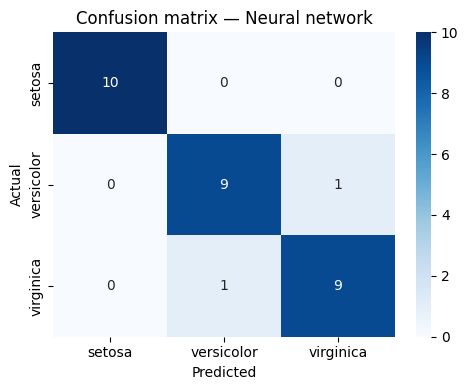

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

# Detailed per-class report
y_pred_prob = model.predict(X_test)          # shape (30, 3) — probability per class
y_pred      = np.argmax(y_pred_prob, axis=1) # take highest-probability class

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion matrix — Neural network')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


New Sample prediction.

In [ ]:
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

# Scaling
new_scaled = scaler.transform(new_sample)

# Predict
probs = model.predict(new_scaled)[0]
probs = np.round(probs, 3)
print(f"Probabilities: {probs}")
pred_class = np.argmax(probs)
pred_name  = iris.target_names[pred_class]
print(f"Predicted class: {pred_name}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Probabilities: [0.995 0.002 0.003]
Predicted class: setosa
